In [86]:
# Install Bioconductor packages (run once)
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

# Install required Bioconductor packages
BiocManager::install(c("clusterProfiler", "org.Hs.eg.db", "DOSE", "enrichplot", "biomaRt"))

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.21 (BiocManager 1.30.25), R 4.5.0 (2025-04-11)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'clusterProfiler' 'org.Hs.eg.db' 'DOSE'
  'enrichplot' 'biomaRt'”


In [87]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(DOSE)
library(ggplot2)
library(dplyr)
library(biomaRt)

In [89]:
# Then use the correct relative path, for example:
deseq_path <- "deseq2_results.csv"
deseq_df <- read.csv(deseq_path)

deseq_path <- "deseq2_results.csv"
if (file.exists(deseq_path)) {
  deseq_df <- read.csv(deseq_path)
  print("File loaded successfully.")
} else {
  stop(paste("File does not exist:", deseq_path))
}

# Filter significant DEGs (padj < 0.05 and |log2FoldChange| >= 1)
sig_genes <- deseq_df %>%
  filter(!is.na(padj)) %>%
  filter(padj < 0.05 & abs(log2FoldChange) >= 1)

dim(sig_genes)
head(sig_genes)

[1] "File loaded successfully."


[1] 2047    7

,Geneid,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AZGP1,249.76937,3.441194,0.3513928,9.793010,1.206492e-22,2.020151e-18
2,PTPRZ1,1026.99399,-1.921802,0.2077337,-9.251277,2.218260e-20,1.553389e-16
3,LOC124903058,69.84722,3.949094,0.4279933,9.227000,2.783187e-20,1.553389e-16
4,PLEKHA4,106.57218,2.830321,0.3102439,9.122892,7.314594e-20,2.449511e-16
5,PCDHGC3,419.51194,-2.508708,0.2747482,-9.130936,6.790959e-20,2.449511e-16
6,LOC124900676,77.92912,3.817423,0.4406355,8.663447,4.577097e-18,1.277315e-14


In [90]:
# Load the biomaRt library to make getBM available
library(biomaRt)

# Define the ensembl mart
ensembl <- useMart("ensembl", dataset = "hsapiens_gene_ensembl")

entrez_map <- getBM(
  attributes = c("external_gene_name", "entrezgene_id", "ensembl_gene_id"),
  filters = "external_gene_name",
  values = sig_genes$Geneid,  # if column is still named "Geneid"
  mart = ensembl
)

# Merge sig_genes with entrez_map to create sig_annot
# Assuming 'Geneid' in sig_genes corresponds to 'external_gene_name' in entrez_map
sig_annot <- merge(sig_genes, entrez_map, by.x = "Geneid", by.y = "external_gene_name", all.x = TRUE)

# You might want to inspect the merged dataframe
head(sig_annot)
dim(sig_annot)

,Geneid,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrezgene_id,ensembl_gene_id
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1,A4GALT,88.18276,2.097770,0.5643181,3.717354,0.0002013200,0.003871970,53947,ENSG00000128274
2,ABCA11P,24.95724,-1.579553,0.4668548,-3.383392,0.0007159636,0.009655103,79963,ENSG00000293360
3,ABCA11P,24.95724,-1.579553,0.4668548,-3.383392,0.0007159636,0.009655103,NA,ENSG00000251595
4,ABCA17P,28.42285,1.522730,0.4568170,3.333349,0.0008580734,0.010884531,NA,ENSG00000238098
5,ABCA17P,28.42285,1.522730,0.4568170,3.333349,0.0008580734,0.010884531,650655,ENSG00000293423
6,ABCA7,310.70451,1.350108,0.4720446,2.860129,0.0042346854,0.031263480,10347,ENSG00000064687


[1] 2109    9

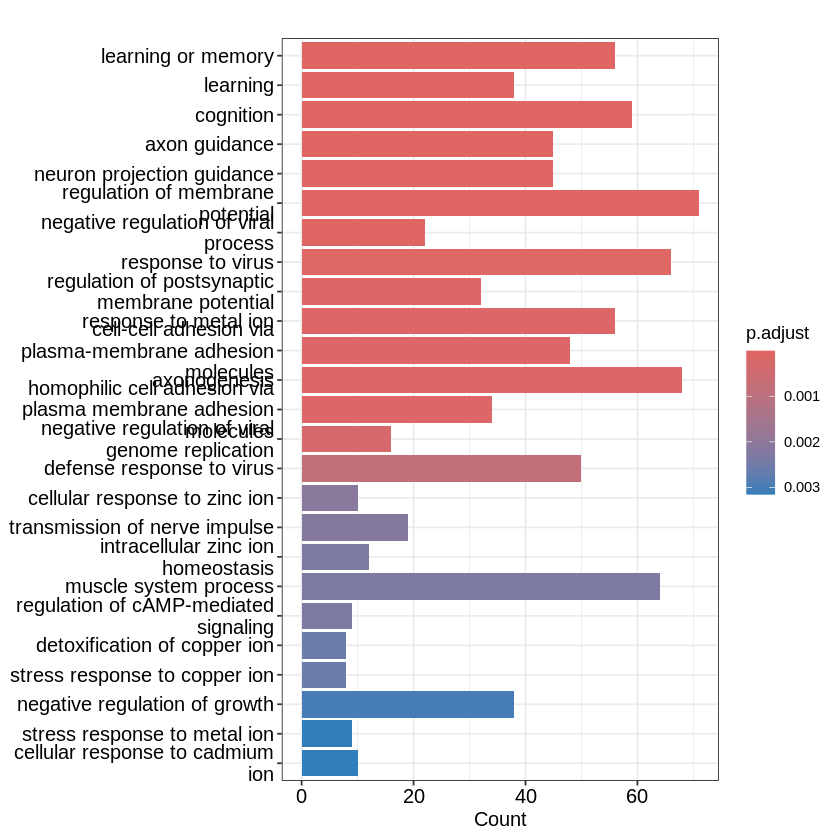

Warning message:
“ggrepel: 116 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


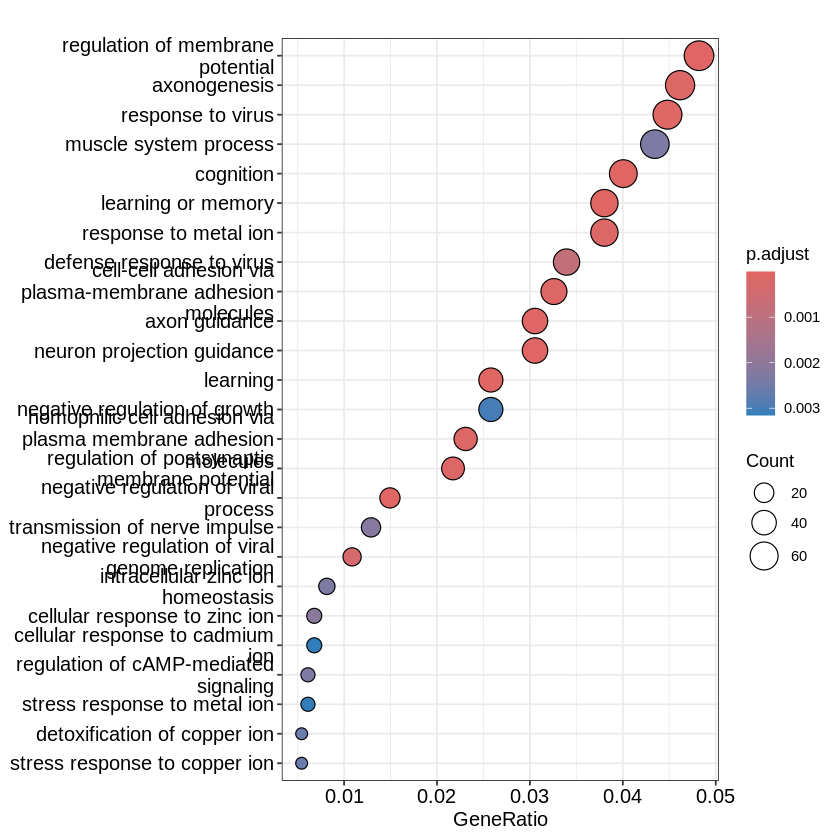

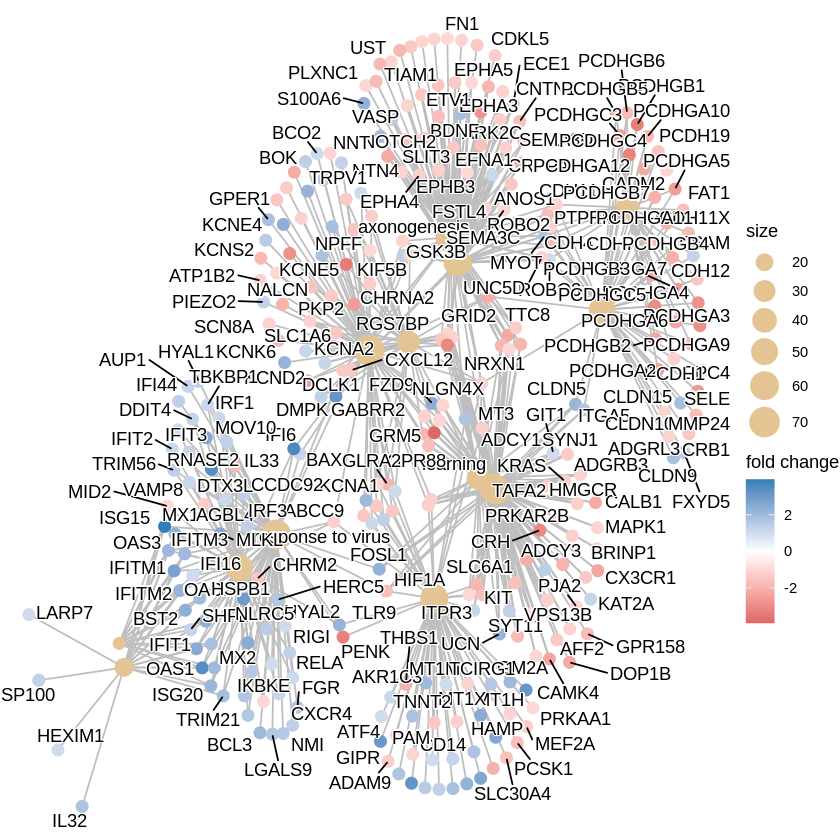

In [91]:
# Load required packages
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(DOSE)
library(ggplot2)
library(dplyr)


# Step 1: Prepare input gene list
sig_annot <- sig_annot %>% filter(!is.na(entrezgene_id))
entrez_ids <- sig_annot$entrezgene_id
entrez_ids <- as.character(entrez_ids)


# Step 2: GO Enrichment Analysis (Biological Process)
ego <- enrichGO(
  gene = entrez_ids,
  OrgDb = org.Hs.eg.db,
  keyType = "ENTREZID",
  ont = "BP",  # <-- Correct parameter
  pAdjustMethod = "BH",
  qvalueCutoff = 0.05,
  readable = TRUE
)

# Step 3: Basic Visualizations
barplot(ego, showCategory = 25)
dotplot(ego, showCategory = 25)

# Step 4: cnetplot using fold changes
fold_changes <- sig_annot$log2FoldChange
names(fold_changes) <- sig_annot$entrezgene_id
fold_changes <- fold_changes[!is.na(names(fold_changes))]

cnetplot(ego, showCategory = 15, foldChange = fold_changes)

# Step 5: goplot fix (ontology must be BP/CC/MF)
#ego@ontology <- "BP"
#goplot(ego)

# Step 6 (Optional): Save results to CSV
write.csv(ego@result, file = "GO_enrichment_results.csv", row.names = FALSE)

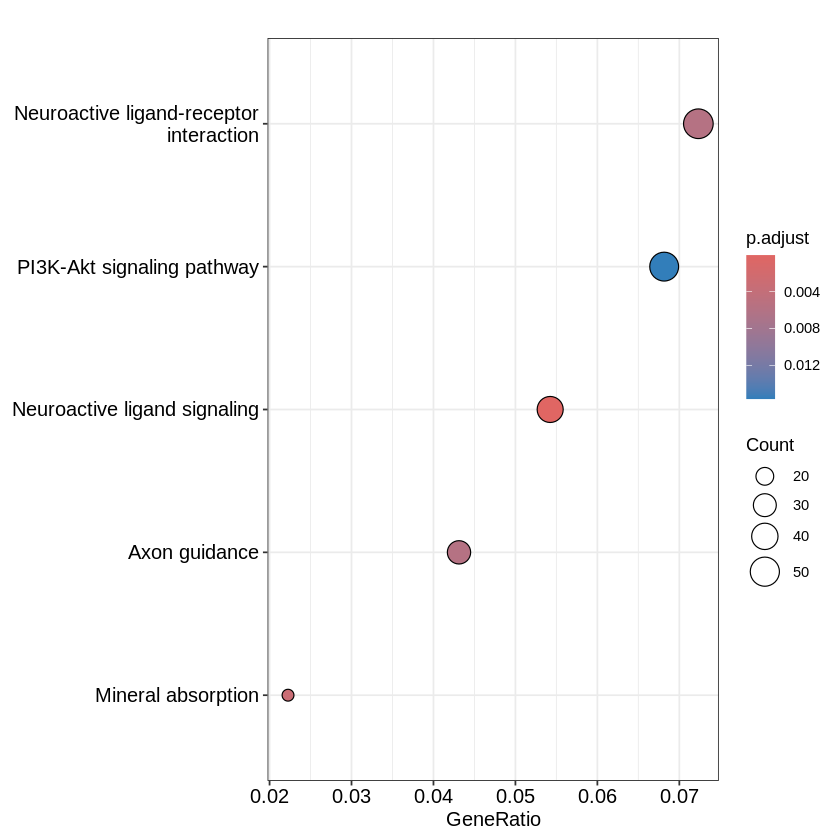

In [92]:
kk <- enrichKEGG(
  gene = entrez_ids,
  organism = "hsa",
  keyType = "kegg",
  pAdjustMethod = "BH",
  qvalueCutoff = 0.05
)
dotplot(kk, showCategory = 20)

In [ ]:
#print(ego@ontology)  # Should output "BP"
#values = sig_genes$gene_id